# Multi-Object Tracking (MOT) — Exercise Notebook

**Goal:** Compare tracking algorithms and study how **detection quality** affects tracking accuracy, stability, and standard MOT metrics.

| Item                     | Details                                                                                                 |
| ------------------------ | ------------------------------------------------------------------------------------------------------- |
| **Target class**         | Human only (`pedestrian` + `people` in VisDrone; **body** boxes from YOLO — **ignore face** detections) |
| **Detector**             | Provided `yolov8x_person_face_local.pt` (YOLOv8x, person + face)                                        |
| **Tracking library**     | [BoxMOT](https://github.com/mikel-brostrom/boxmot) (or equivalent)                                      |
| **Required trackers**    | ByteTrack, BoTSORT, OC-SORT, DeepOCSORT, StrongSORT, HybridSORT, BoostTrack                             |
| **Metrics (Stages 3–4)** | [motmetrics](https://github.com/cheind/py-motmetrics)                                                   |
| **Datasets**             | Three VisDrone2019-MOT sequences: `1`, `2`, `3` under `VisDrone2019-MOT/`                               |

### Stages (overview)

1. **Initial qualitative assessment** — provided YOLO + YOLO ByteTrack videos on dataset 1
2. **Detection improvement** — fine-tune the provided detector; numeric eval vs GT
3. **Tracking comparison (dataset 1)** — BoxMOT + motmetrics; tables, videos, top-3 trackers
4. **Generalization (datasets 2 & 3)** — best detector from Stage 2, same trackers, cross-dataset analysis
5. **Comprehensive error analysis** — failure scenarios, detection ↔ tracking link

> AI tools are allowed, but you must fully understand and be able to explain every method, parameter, and result in your presentation.


## Setup: install dependencies and download exercise files

Run this section once before the rest of the notebook. It downloads only the needed assets: `models`, `sample.jpg`, and `VisDrone2019-MOT`. The shared notebook file is intentionally ignored.


In [1]:
%pip install motmetrics --quiet
%pip install ultralytics opencv-python matplotlib pyyaml numpy pandas tqdm boxmot wget --quiet

import numpy as np
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=float: np.asarray(a, dtype=dtype)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of th

## Note
In this part I have downloaded the weights using google drive and not the IUST drive. The homework Datasets and models were uploaded to google drive by kamyar moradian so shout out to him for sharing the files.

In [2]:
from pathlib import Path

# 1. Define project root
PROJECT_ROOT = Path(".").resolve()

# 2. Define all required subdirectories
DOWNLOAD_DIR = PROJECT_ROOT / "downloads"
ASSETS_EXTRACT_DIR = DOWNLOAD_DIR / "notebook_models_sample"
DATASET_EXTRACT_DIR = DOWNLOAD_DIR / "visdrone_dataset"

# 3. List and create them safely
directories_to_create = [
    DOWNLOAD_DIR,
    ASSETS_EXTRACT_DIR,
    DATASET_EXTRACT_DIR,
]

for directory in directories_to_create:
    directory.mkdir(parents=True, exist_ok=True)
    print(f"Ensured directory exists: {directory.relative_to(PROJECT_ROOT)}")

print("Directory setup complete!")

from pathlib import Path
from urllib.request import Request, urlopen
from zipfile import ZipFile, is_zipfile
import shutil
import subprocess
import gdown

ASSETS_SHARE_URL = "https://drive.google.com/file/d/179cltMNGPqgZrsCt4ctuaJFnxcmDoPr1/view?usp=sharing"
DATASET_SHARE_URL = "https://drive.google.com/file/d/1sD47NBXxBzhVShFd92LtJ8-EvoFWYgOz/view?usp=sharing"
ASSETS_ZIP = DOWNLOAD_DIR / "notebook_models_sample.zip"
DATASET_ZIP = DOWNLOAD_DIR / "visdrone_dataset.zip"

EXPECTED_ITEMS = {
    "models": PROJECT_ROOT / "models",
    "sample.jpg": PROJECT_ROOT / "sample.jpg",
    "VisDrone2019-MOT": PROJECT_ROOT / "VisDrone2019-MOT",
}

def download_archive(share_url, output_path):
    if "/d/" in share_url:
        file_id = share_url.split("/d/")[1].split("/")[0]
        print(f"Downloading {output_path.name}...")
        gdown.download(id=file_id, output=str(output_path), quiet=False)
    else:
        print(f"Error: Could not parse file ID from URL {share_url}")


def extract_zip(zip_path, extract_dir):
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with ZipFile(zip_path) as zip_file:
        zip_file.extractall(extract_dir)


def find_first(root, name, is_dir):
    matches = [path for path in root.rglob(name) if path.is_dir() == is_dir]
    return min(matches, key=lambda path: len(path.parts), default=None)


def find_visdrone_root(root):
    named_root = find_first(root, "VisDrone2019-MOT", is_dir=True)
    if named_root is not None:
        return named_root

    for path in root.rglob("*"):
        if (
            path.is_dir()
            and (path / "sequences").exists()
            and (path / "annotations").exists()
        ):
            return path
    return None


def copy_if_missing(source, destination):
    if destination.exists():
        print(f"Skipping existing {destination}")
        return
    if source.is_dir():
        shutil.copytree(source, destination)
    else:
        shutil.copy2(source, destination)
    print(f"Ready: {destination}")


if not all(path.exists() for path in EXPECTED_ITEMS.values()):
    download_archive(ASSETS_SHARE_URL, ASSETS_ZIP)
    download_archive(DATASET_SHARE_URL, DATASET_ZIP)

    extract_zip(ASSETS_ZIP, ASSETS_EXTRACT_DIR)
    extract_zip(DATASET_ZIP, DATASET_EXTRACT_DIR)

    models_source = find_first(ASSETS_EXTRACT_DIR, "models", is_dir=True)
    sample_source = find_first(ASSETS_EXTRACT_DIR, "sample.jpg", is_dir=False)
    dataset_source = find_visdrone_root(DATASET_EXTRACT_DIR)

    if models_source is None:
        raise FileNotFoundError("Could not find models inside the assets archive.")
    if sample_source is None:
        raise FileNotFoundError("Could not find sample.jpg inside the assets archive.")
    if dataset_source is None:
        raise FileNotFoundError(
            "Could not find the VisDrone dataset inside the dataset archive."
        )

    copy_if_missing(models_source, EXPECTED_ITEMS["models"])
    copy_if_missing(sample_source, EXPECTED_ITEMS["sample.jpg"])
    copy_if_missing(dataset_source, EXPECTED_ITEMS["VisDrone2019-MOT"])
else:
    print("Exercise files already exist; skipping download and extraction.")

Ensured directory exists: downloads
Ensured directory exists: downloads/notebook_models_sample
Ensured directory exists: downloads/visdrone_dataset
Directory setup complete!


Downloading...
From (original): https://drive.google.com/uc?id=179cltMNGPqgZrsCt4ctuaJFnxcmDoPr1
From (redirected): https://drive.google.com/uc?id=179cltMNGPqgZrsCt4ctuaJFnxcmDoPr1&confirm=t&uuid=ec386d3c-0191-4066-bc22-ce4a85531309
To: /kaggle/working/downloads/notebook_models_sample.zip
100%|██████████| 258M/258M [00:03<00:00, 82.8MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1sD47NBXxBzhVShFd92LtJ8-EvoFWYgOz
From (redirected): https://drive.google.com/uc?id=1sD47NBXxBzhVShFd92LtJ8-EvoFWYgOz&confirm=t&uuid=5041ba2b-84fa-464f-94c4-e8849da7cf95
To: /kaggle/working/downloads/visdrone_dataset.zip
100%|██████████| 334M/334M [00:03<00:00, 111MB/s]


Ready: /kaggle/working/models
Ready: /kaggle/working/sample.jpg
Ready: /kaggle/working/VisDrone2019-MOT


In [3]:
from pathlib import Path

# Project paths (adjust if your folder layout differs)
PROJECT_ROOT = Path(".").resolve()
VISDRONE_ROOT = PROJECT_ROOT / "VisDrone2019-MOT"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODELS_DIR / "yolov8x_person_face_local.pt"
SAMPLE_IMAGE = PROJECT_ROOT / "sample.jpg"
OUTPUT_DIR = PROJECT_ROOT / "output"
CACHE_DIR = PROJECT_ROOT / "cache"

DATASET_IDS = ["1", "2", "3"]  # three exercise datasets
DATASET_1 = "1"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## Load detector and run on a sample image

Run this cell first. It loads the provided YOLOv8x person/face model and visualizes detections on `sample.jpg`.

**Note:** For all exercise work, use **person (body)** boxes only — **ignore face** class outputs.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model summary (fused): 112 layers, 68,125,494 parameters, 0 gradients, 257.4 GFLOPs

image 1/1 /kaggle/working/sample.jpg: 384x640 11 persons, 14 faces, 136.3ms
Speed: 11.7ms preprocess, 136.3ms inference, 29.2ms postprocess per image at shape (1, 3, 384, 640)


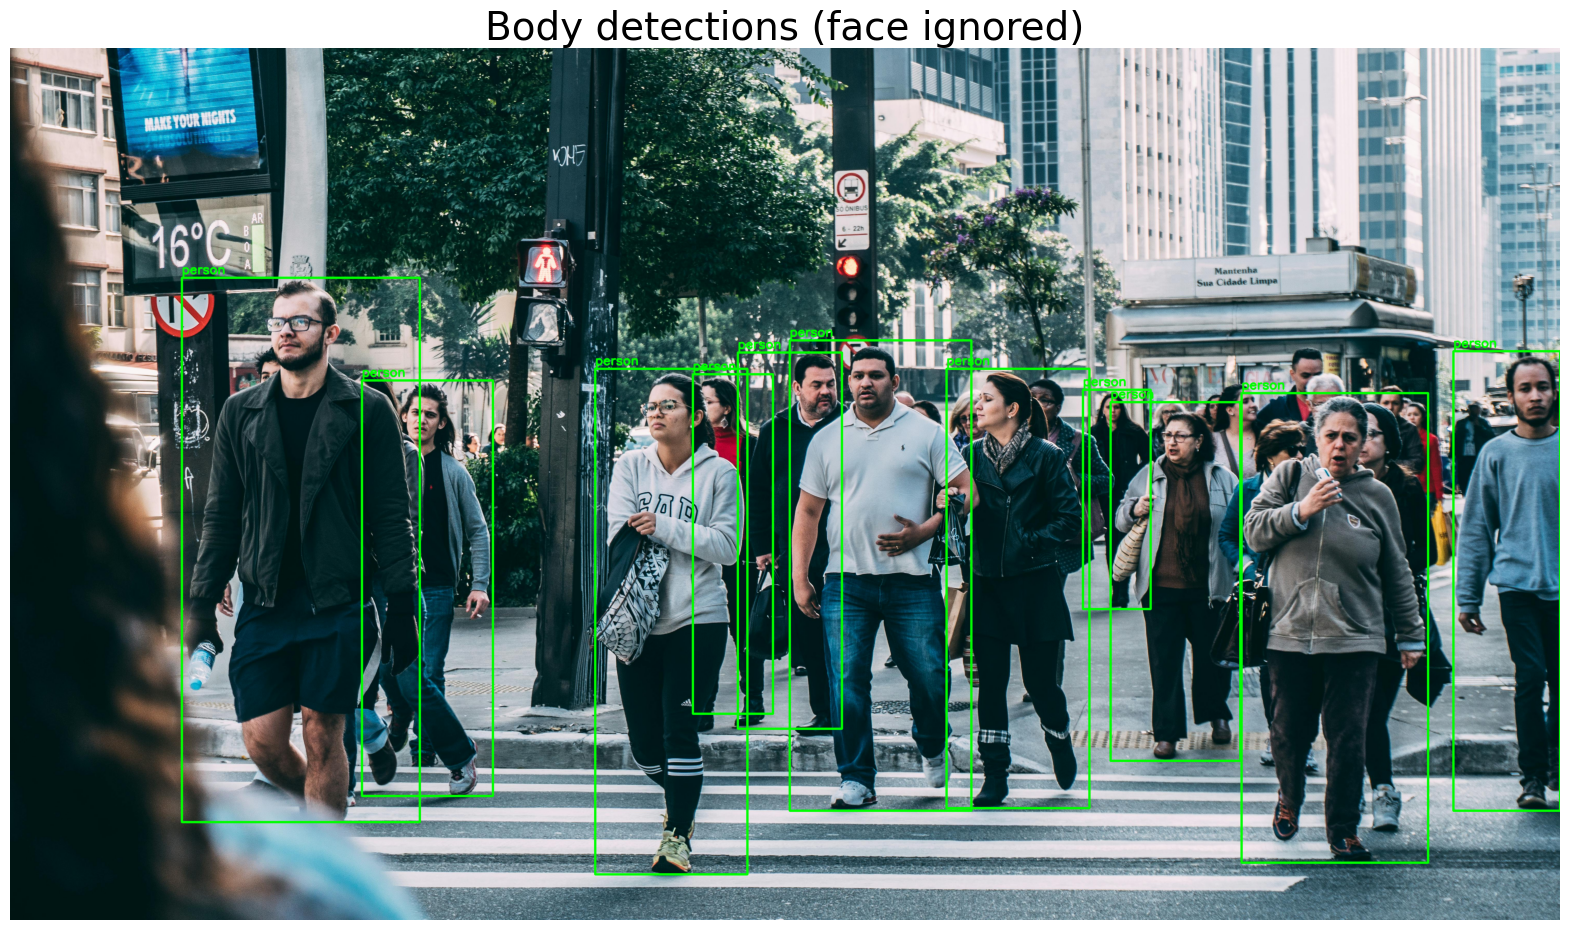

In [4]:
from ultralytics import YOLO
import torch
import cv2
import matplotlib.pyplot as plt

# 1. Load model
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = YOLO(str(MODEL_PATH))
model.fuse()
if torch_dtype is torch.float16:
    model.model = model.model.half()
model.to(device)

# Person = body; face detections are ignored in this exercise
BODY_CLASS_IDS = {i for i, n in model.names.items() if n.lower() == "person"}

# 2. Inference on sample image
image = str(SAMPLE_IMAGE)
results = model.predict(image, conf=0.4, iou=0.7, half=torch_dtype is torch.float16)

# 3. Visualize (body only)
for result in results:
    img = cv2.imread(image)
    for box, cls in zip(
        result.boxes.xyxy.cpu().numpy(), result.boxes.cls.cpu().numpy()
    ):
        if int(cls) not in BODY_CLASS_IDS:
            continue
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 7)
        cv2.putText(
            img,
            "person",
            (x1, y1 - 16),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.6,
            (0, 255, 0),
            5,
        )
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(20, 13))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Body detections (face ignored)", fontsize=28)
    plt.show()


## Dataset format (VisDrone2019-MOT)

Each sequence lives in `VisDrone2019-MOT/sequences/<id>/` (frames: `0000001.jpg`, …).  
Annotations: `VisDrone2019-MOT/annotations/<id>.txt` — **one object per line**, comma-separated:

| #   | Field                            | Meaning                                  |
| --- | -------------------------------- | ---------------------------------------- |
| 1   | `frame_index`                    | Frame number (matches `int(frame_stem)`) |
| 2   | `target_id`                      | Track ID                                 |
| 3–6 | `left`, `top`, `width`, `height` | Bounding box (pixels)                    |
| 7   | `score`                          | `0` = ignore in evaluation               |
| 8   | `object_category`                | Class ID (see below)                     |
| 9   | `truncation`                     | 0 / 1                                    |
| 10  | `occlusion`                      | 0, 1, or 2                               |

**Human classes for this exercise:** `1` = pedestrian, `2` = people (treat both as _human_ GT).

| ID   | Class             |
| ---- | ----------------- |
| 0    | ignored           |
| 1    | pedestrian        |
| 2    | people            |
| 3–10 | vehicles / others |
| 11   | others            |

**Box corners:** `x_max = left + width`, `y_max = top + height`.


In [5]:
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
from IPython.display import Video, display

VISDRONE_CLASSES = {
    0: "ignored",
    1: "pedestrian",
    2: "people",
    3: "bicycle",
    4: "car",
    5: "van",
    6: "truck",
    7: "tricycle",
    8: "awning-tricycle",
    9: "bus",
    10: "motor",
    11: "others",
}
HUMAN_GT_CATEGORIES = {1, 2}


def load_visdrone_mot_annotations(ann_path):
    """Parse VisDrone-MOT txt → dict[frame_index] → list of detections."""
    by_frame = defaultdict(list)
    with open(ann_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            p = list(map(int, line.split(",")))
            frame_idx, target_id, left, top, w, h, score, category, trunc, occ = p
            if score == 0:
                continue
            by_frame[frame_idx].append(
                {
                    "target_id": target_id,
                    "bbox": (left, top, w, h),
                    "category": category,
                    "truncation": trunc,
                    "occlusion": occ,
                }
            )
    return by_frame


def track_color(track_id):
    rng = np.random.default_rng(int(track_id))
    return tuple(int(x) for x in rng.integers(64, 256, size=3))


def show_video(path, width=960):
    display(Video(str(path), embed=True, width=width))


def sequence_paths(seq_id, root=VISDRONE_ROOT):
    root = Path(root)
    seq_dir = root / "sequences" / str(seq_id)
    ann_path = root / "annotations" / f"{seq_id}.txt"
    frames = sorted(seq_dir.glob("*.jpg"))
    return seq_dir, ann_path, frames


---

## Stage 1 — Initial qualitative assessment (Dataset 1)

**Tasks**

1. Run the **provided YOLOv8x** model on **dataset 1**.
2. Produce **two videos**: (a) **detection only**, (b) **tracking** with YOLO’s built-in **ByteTrack** (`model.track(..., tracker="bytetrack.yaml")`).
3. No numeric report required — write a **qualitative analysis** below.

**Observe:** missed/false detections, ID switches, fragmentation, occlusion handling, scale/speed, crowd density, lighting/background.

### 1.1 Visualize ground truth (optional sanity check)


In [6]:
# Stage 1.1 – Render ground-truth human tracks for dataset 1 (sanity check)
import cv2
import numpy as np

SEQ = DATASET_1
_, ann_path, frame_files = sequence_paths(SEQ)
annotations = load_visdrone_mot_annotations(ann_path)

out_path = OUTPUT_DIR / f"{SEQ}_gt_human.mp4"
sample_img = cv2.imread(str(frame_files[0]))
h, w = sample_img.shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(out_path), fourcc, 10.0, (w, h))

for img_path in frame_files:
    frame_idx = int(img_path.stem)
    img = cv2.imread(str(img_path))
    for det in annotations.get(frame_idx, []):
        if det["category"] not in HUMAN_GT_CATEGORIES:
            continue
        l, t, bw, bh = det["bbox"]
        tid = det["target_id"]
        color = track_color(tid)
        cv2.rectangle(img, (l, t), (l + bw, t + bh), color, 2)
        cv2.putText(img, f"GT {tid}", (l, t - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    writer.write(img)

writer.release()
print(f"GT video saved → {out_path}")

GT video saved → /kaggle/working/output/1_gt_human.mp4


### 1.2 Detection video (provided model, dataset 1)


In [7]:
# Stage 1.2 – Detection-only video with provided YOLOv8x (body only)
import cv2

SEQ = DATASET_1
_, _, frame_files = sequence_paths(SEQ)
out_path = OUTPUT_DIR / f"{SEQ}_stage1_detection.mp4"

sample_img = cv2.imread(str(frame_files[0]))
h, w = sample_img.shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(out_path), fourcc, 10.0, (w, h))

for img_path in frame_files:
    result = model.predict(str(img_path), conf=0.4, iou=0.7, verbose=False)[0]
    img = cv2.imread(str(img_path))
    for box, cls, conf in zip(
        result.boxes.xyxy.cpu().numpy(),
        result.boxes.cls.cpu().numpy(),
        result.boxes.conf.cpu().numpy(),
    ):
        if int(cls) not in BODY_CLASS_IDS:
            continue
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{conf:.2f}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    writer.write(img)

writer.release()
print(f"Detection video saved → {out_path}")

Detection video saved → /kaggle/working/output/1_stage1_detection.mp4


### 1.3 Tracking video (YOLO + built-in ByteTrack)


In [8]:
# Stage 1.3 – Tracking video: YOLO built-in ByteTrack (body only)
import cv2
from pathlib import Path

SEQ = DATASET_1
seq_dir, _, frame_files = sequence_paths(SEQ)
out_path = OUTPUT_DIR / f"{SEQ}_stage1_bytetrack.mp4"

# model.track() with persist=True processes frames sequentially;
# we pass the sequence folder so YOLO streams all frames in order.
track_results = model.track(
    source=str(seq_dir),
    tracker="bytetrack.yaml",
    persist=True,
    conf=0.4,
    iou=0.7,
    half=(torch.cuda.is_available()),
    stream=True,
    verbose=False,
)

sample_img = cv2.imread(str(frame_files[0]))
h, w = sample_img.shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(out_path), fourcc, 10.0, (w, h))

for img_path, result in zip(frame_files, track_results):
    img = cv2.imread(str(img_path))
    if result.boxes is None or result.boxes.id is None:
        writer.write(img)
        continue
    for box, cls, tid in zip(
        result.boxes.xyxy.cpu().numpy(),
        result.boxes.cls.cpu().numpy(),
        result.boxes.id.cpu().numpy(),
    ):
        if int(cls) not in BODY_CLASS_IDS:
            continue
        x1, y1, x2, y2 = map(int, box)
        tid_int = int(tid)
        color = track_color(tid_int)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, f"ID {tid_int}", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    writer.write(img)

writer.release()
print(f"ByteTrack video saved → {out_path}")

ByteTrack video saved → /kaggle/working/output/1_stage1_bytetrack.mp4


### 1.4 Analysis

#### Only detection
This method is not optimal. There are frames were none of the people in the frame are detected. For example in the 31st second there is a brief moment were nothing is detected. On the other hand after a person is detected in the first frame, it is usually lost in the next one. The model has know understanding of motion and detection in motion so it is handling each image separately.

#### bytetrack
I think bytetrack performs better than the only detection method. For example there are a couple of detections in the 31st second were yolo failed. So having some sort of physical understanding enhances detection quality. Although a problem evident is the amount of id switches in this method at the current state. I believe fine-tuning the method on this dataset would greatly improve the quality of predictions.


## Stage 2 — Improve detection (Dataset 1)

Fine-tune `yolov8x_person_face_local.pt` on dataset 1 using the human ground-truth labels.

Evaluate the fine-tuned detector against **ground truth** on dataset 1: **mAP**, **Precision**, **Recall**, **F1** (YOLO `val()` or custom matching).  
Use the fine-tuned model as the detector for the tracking stages.

> Training cells below build a YOLO dataset from VisDrone GT (pedestrian + people → `person` class). Face labels are not in GT; the detector still has 2 heads after training — continue to **ignore face** at inference.


In [9]:
from pathlib import Path
import random
import shutil

import cv2
import yaml

SEQ = DATASET_1
DATASET_ROOT = Path("datasets") / f"visdrone_{SEQ}_person"

VISDRONE_PERSON_CATS = HUMAN_GT_CATEGORIES
YOLO_CLASS_PERSON = 0
VAL_FRACTION = 0.2
SEED = 42
random.seed(SEED)


def visdrone_to_yolo_line(left, top, w, h, img_w, img_h, class_id=YOLO_CLASS_PERSON):
    """Convert a VisDrone ltwh box to YOLO normalised cx cy w h format."""
    x_c = (left + w / 2) / img_w
    y_c = (top + h / 2) / img_h
    return f"{class_id} {x_c:.6f} {y_c:.6f} {w / img_w:.6f} {h / img_h:.6f}"


def build_person_yolo_dataset(
    seq_id=SEQ,
    root=VISDRONE_ROOT,
    out_root=DATASET_ROOT,
    val_fraction=VAL_FRACTION,
):
    root = Path(root)
    out_root = Path(out_root)

    seq_dir, ann_path, frame_files = sequence_paths(seq_id, root)
    by_frame = load_visdrone_mot_annotations(ann_path)

    raw_rows = 0
    kept_human_rows = 0
    with open(ann_path, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            raw_rows += 1
            parts = list(map(int, line.split(",")))
            score, category = parts[6], parts[7]
            if score != 0 and category in VISDRONE_PERSON_CATS:
                kept_human_rows += 1
    print(f"Annotation file: {raw_rows} total rows, {kept_human_rows} human rows with score!=0")
    if kept_human_rows == 0:
        raise ValueError(
            f"No human annotations with score!=0 found in {ann_path}.\n"
            "All rows appear to have score=0 (ignore flag). "
            "Check the annotation file or remove the score==0 filter in "
            "load_visdrone_mot_annotations if the dataset uses a different convention."
        )

    sample = cv2.imread(str(frame_files[0]))
    img_h, img_w = sample.shape[:2]

    for sub in ("train", "val"):
        (out_root / "images" / sub).mkdir(parents=True, exist_ok=True)
        (out_root / "labels" / sub).mkdir(parents=True, exist_ok=True)

    shuffled = frame_files.copy()
    random.shuffle(shuffled)
    n_val = max(1, int(len(shuffled) * val_fraction))
    val_set = {f.resolve() for f in shuffled[:n_val]}

    def write_split(split_name, files):
        frames_with_labels = 0
        for img_path in sorted(files, key=lambda p: int(p.stem)):
            frame_idx = int(img_path.stem)

            img_link = out_root / "images" / split_name / img_path.name
            if not img_link.exists():
                img_link.symlink_to(img_path.resolve())

            label_path = out_root / "labels" / split_name / f"{img_path.stem}.txt"
            yolo_lines = []
            for det in by_frame.get(frame_idx, []):
                if det["category"] not in VISDRONE_PERSON_CATS:
                    continue
                left, top, bw, bh = det["bbox"]

                if bw <= 0 or bh <= 0:
                    continue
                yolo_lines.append(
                    visdrone_to_yolo_line(left, top, bw, bh, img_w, img_h)
                )
            label_path.write_text("\n".join(yolo_lines), encoding="utf-8")
            if yolo_lines:
                frames_with_labels += 1

        print(f"  {split_name}: {len(files)} frames, "
              f"{frames_with_labels} have >=1 person label")
        return len(files)

    train_files = [f for f in frame_files if f.resolve() not in val_set]
    val_files   = [f for f in frame_files if f.resolve() in val_set]
    write_split("train", train_files)
    write_split("val",   val_files)

    data_yaml = {
        "path": str(out_root.resolve()),
        "train": "images/train",
        "val":   "images/val",
        "nc": 2,
        "names": ["person", "face"],
    }
    yaml_path = out_root / "data.yaml"
    yaml_path.write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding="utf-8")
    print(f"data.yaml written ? {yaml_path}")
    return yaml_path


DATA_YAML = build_person_yolo_dataset()

for split in ("train", "val"):
    label_dir = DATASET_ROOT / "labels" / split
    all_labels   = list(label_dir.glob("*.txt"))
    non_empty    = [f for f in all_labels if f.stat().st_size > 0]
    print(f"{split}: {len(non_empty)}/{len(all_labels)} label files non-empty")
print("Sample label:", (DATASET_ROOT / "labels" / "train" / 
      sorted((DATASET_ROOT / "labels" / "train").glob("*.txt"))[0].name).read_text()[:200])


Annotation file: 23877 total rows, 22098 human rows with score!=0
  train: 372 frames, 372 have >=1 person label
  val: 92 frames, 92 have >=1 person label
data.yaml written ? datasets/visdrone_1_person/data.yaml
train: 372/372 label files non-empty
val: 92/92 label files non-empty
Sample label: 0 0.199405 0.410714 0.016369 0.059524
0 0.220610 0.417989 0.011161 0.047619
0 0.236979 0.407407 0.014137 0.047619
0 0.331101 0.279101 0.017857 0.052910
0 0.245908 0.405423 0.015625 0.062169
0 0.229167


In [10]:
from ultralytics import YOLO

# --- training config (reduce batch/imgsz if GPU OOM) ---
EPOCHS = 20
IMGSZ = 640
BATCH = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"

BASE_MODEL = MODEL_PATH
FINETUNED_LOCAL = MODELS_DIR / "yolov8x_person_face_finetuned.pt"

train_kw = dict(
    data=str(DATA_YAML.resolve()),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project="runs/train",
    exist_ok=True,
    verbose=True,
)

print("=== Fine-tuning provided model ===")
ft_model = YOLO(str(BASE_MODEL))
ft_results = ft_model.train(name="finetune_person_face", **train_kw)
shutil.copy2(Path(ft_results.save_dir) / "weights" / "best.pt", FINETUNED_LOCAL)
print(f"Fine-tuned -> {FINETUNED_LOCAL}")

model_finetuned = YOLO(str(FINETUNED_LOCAL))


=== Fine-tuning provided model ===
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/visdrone_1_person/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/models/yolov8x_person_face_local.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune

### 2.1 Numeric detection evaluation vs ground truth


In [11]:
from ultralytics import YOLO

DEVICE_VAL = 0 if torch.cuda.is_available() else "cpu"

metrics_finetuned = model_finetuned.val(
    data=str(DATA_YAML),
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE_VAL,
    conf=0.4,
    iou=0.5,
    verbose=True,
    project="runs/val",
    name="finetune_person_face_val",
    exist_ok=True,
)

mp  = float(metrics_finetuned.box.mp)
mr  = float(metrics_finetuned.box.mr)
map50   = float(metrics_finetuned.box.map50)
map5095 = float(metrics_finetuned.box.map)
f1  = 2 * mp * mr / (mp + mr + 1e-9)

import pandas as pd
df_det = pd.DataFrame([{
    "Model": "Fine-tuned YOLOv8x",
    "mAP@50": f"{map50:.3f}",
    "mAP@50-95": f"{map5095:.3f}",
    "Precision": f"{mp:.3f}",
    "Recall": f"{mr:.3f}",
    "F1": f"{f1:.3f}",
}])
print(df_det.to_string(index=False))


Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 68,125,494 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2653.5±1297.8 MB/s, size: 154.2 KB)
val: Scanning /kaggle/working/datasets/visdrone_1_person/labels/val.cache... 92 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 38.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.0it/s 5.9s
                   all         92       4247       0.98      0.932      0.932       0.69
                person         92       4247       0.98      0.932      0.932       0.69
Speed: 1.3ms preprocess, 52.3ms inference, 0.0ms loss, 5.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/runs/val/finetune_person_face_val
             Model mAP@50 mAP@50-95 Precision Recall    F1
Fine-tuned YOLOv8x  0.932     0.690     0.980  0.932 0.955


### 2.2 Analysis

All the calculated scores have improved in the 20 fine-tuning epochs and all the losses have decreased drastically. For example the precision and recall of the predicted box has increased from 0.77 and 0.65 in the first epoch to 0.96 and 0.94 in the 20th epoch respectively. In the end the model has reached a precision of 0.98 and recall of 0.93 after finetuning on the first dataset.


In [12]:
# Set the fine-tuned detector for tracking experiments
BEST_DETECTOR = FINETUNED_LOCAL
detector = YOLO(str(BEST_DETECTOR))


## Stage 3 — Tracking algorithms on Dataset 1

Use **your best detector from Stage 2** as input to each tracker (BoxMOT recommended).

| Tracker    | BoxMOT tracker name (example) |
| ---------- | ----------------------------- |
| ByteTrack  | `bytetrack`                   |
| BoTSORT    | `botsort`                     |
| OC-SORT    | `ocsort`                      |
| DeepOCSORT | `deepocsort`                  |
| StrongSORT | `strongsort`                  |
| HybridSORT | `hybridsort`                  |
| BoostTrack | `boosttrack`                  |

**Evaluate** with `motmetrics` (MOTA, IDF1, IDS, FP, FN, …).  
Deliver: comparison **table**, sample **videos**, **top-3** trackers with technical justification.


In [13]:
import torch
import cv2
import numpy as np
import pandas as pd
import motmetrics as mm
from pathlib import Path
from tqdm import tqdm


from boxmot.trackers import (
    ByteTrack,
    BotSort,
    OcSort,
    DeepOcSort,
    StrongSort,
    HybridSort,
    BoostTrack,
)

CONF_THRESH  = 0.4
IOU_THRESH   = 0.7
DEVICE_TRACK = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
FP16         = DEVICE_TRACK.type == "cuda"
REID_WEIGHTS = Path("/kaggle/input/datasets/sinatb/osnet-x0-25-msmt17/osnet_x0_25_msmt17.pt")  

TRACKER_REGISTRY = {
    "bytetrack":  (ByteTrack,  False),
    "ocsort":     (OcSort,     False),
    "botsort":    (BotSort,    True),
    "deepocsort": (DeepOcSort, True),
    "strongsort": (StrongSort, True),
    "hybridsort": (HybridSort, True),
    "boosttrack": (BoostTrack, True),
}

TRACKERS = list(TRACKER_REGISTRY.keys())
SEQ = DATASET_1
seq_dir, ann_path, frame_files = sequence_paths(SEQ)
gt_by_frame = load_visdrone_mot_annotations(ann_path)
sample_img  = cv2.imread(str(frame_files[0]))

from boxmot.reid.core.reid import PyTorchBackend

reid_model = PyTorchBackend(
    weights=str(REID_WEIGHTS),
    device=DEVICE_TRACK,
    half=FP16
)


def make_tracker(tracker_name):
    cls, needs_reid = TRACKER_REGISTRY[tracker_name]
    if needs_reid:
        return cls(
            reid_model=reid_model,
            device=DEVICE_TRACK,
            fp16=FP16,
        )
    else:
        return cls()


def run_tracker_sequence(tracker_name, seq_id, frame_files, gt_by_frame,
                          det_model, save_video=True):
    tracker = make_tracker(tracker_name)
    acc = mm.MOTAccumulator(auto_id=True)

    if save_video:
        vid_path = OUTPUT_DIR / f"{seq_id}_{tracker_name}.mp4"
        sample   = cv2.imread(str(frame_files[0]))
        h, w     = sample.shape[:2]          # read from THIS sequence
        fourcc   = cv2.VideoWriter_fourcc(*"mp4v")
        writer   = cv2.VideoWriter(str(vid_path), fourcc, 10.0, (w, h))

    for img_path in tqdm(frame_files, desc=tracker_name, leave=False):
        frame_idx = int(img_path.stem)
        img_bgr   = cv2.imread(str(img_path))

        result  = det_model.predict(
            str(img_path), conf=CONF_THRESH, iou=IOU_THRESH, verbose=False
        )[0]
        boxes   = result.boxes.xyxy.cpu().numpy()
        confs   = result.boxes.conf.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)

        mask = np.array([c in BODY_CLASS_IDS for c in classes])
        if mask.sum() > 0:
            dets = np.hstack([boxes[mask], confs[mask, None], classes[mask, None]])
        else:
            dets = np.empty((0, 6))

        tracks = tracker.update(dets, img_bgr)

        gt_dets  = [d for d in gt_by_frame.get(frame_idx, [])
                    if d["category"] in HUMAN_GT_CATEGORIES]
        gt_ids   = [d["target_id"] for d in gt_dets]
        gt_boxes = [list(d["bbox"]) for d in gt_dets]  # [l, t, w, h]

        pred_ids, pred_boxes = [], []
        if len(tracks) > 0:
            for t in tracks:
                x1, y1, x2, y2, tid = t[0], t[1], t[2], t[3], t[4]
                pred_ids.append(int(tid))
                pred_boxes.append([x1, y1, x2 - x1, y2 - y1])

        dist = mm.distances.iou_matrix(gt_boxes, pred_boxes, max_iou=0.5)
        acc.update(gt_ids, pred_ids, dist)

        if save_video:
            vis = img_bgr.copy()
            for t in tracks:
                x1, y1, x2, y2, tid = map(int, t[:5])
                color = track_color(tid)
                cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
                cv2.putText(vis, f"ID {tid}", (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
            writer.write(vis)

    if save_video:
        writer.release()
        print(f"  Video ? {vid_path}")

    return acc


mh = mm.metrics.create()
results_stage3 = {}

for tracker_name in TRACKERS:
    print(f"\n>>> {tracker_name} on dataset {SEQ} ...")
    acc = run_tracker_sequence(
        tracker_name, SEQ, frame_files, gt_by_frame,
        detector, save_video=True,
    )
    summary = mh.compute(
        acc,
        metrics=["num_frames", "mota", "idf1", "num_switches",
                 "num_false_positives", "num_misses", "precision", "recall"],
        name=tracker_name,
    )
    results_stage3[tracker_name] = summary

df_stage3 = pd.concat(results_stage3.values())
df_stage3.index.name = "Tracker"
df_stage3.rename(columns={
    "mota": "MOTA", "idf1": "IDF1",
    "num_switches": "IDS",
    "num_false_positives": "FP",
    "num_misses": "FN",
    "precision": "Prec", "recall": "Rec",
}, inplace=True)
df_stage3.drop(columns=["num_frames"], errors="ignore", inplace=True)
df_stage3[["MOTA", "IDF1", "IDS", "FP", "FN", "Prec", "Rec"]] = (
    df_stage3[["MOTA", "IDF1", "IDS", "FP", "FN", "Prec", "Rec"]].round(3)
)

print("\n=== Stage 3 ? Tracking results on Dataset 1 ===")
print(df_stage3.to_string())

all_results = {SEQ: df_stage3.copy()}

top3 = df_stage3.nlargest(3, "MOTA").index.tolist()
print(f"\nTop-3 trackers by MOTA: {top3}")


INFO     /kaggle/input/datasets/sinatb/osnet-x0-25-msmt17/osnet_x0_25_msmt17.pt

INFO     [PID 23] Found existing ReID weights at                                                                   
         /kaggle/input/datasets/sinatb/osnet-x0-25-msmt17/osnet_x0_25_msmt17.pt; skipping download.

INFO     Loaded pretrained weights from /kaggle/input/datasets/sinatb/osnet-x0-25-msmt17/osnet_x0_25_msmt17.pt


>>> bytetrack on dataset 1 ...


INFO     ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,        
         asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30

...

  Video ? /kaggle/working/output/1_strongsort.mp4

>>> hybridsort on dataset 1 ...


INFO     HybridSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         asso_func=iou, reid_model=<boxmot.reid.backends.pytorch_backend.PyTorchBackend object at 0x7ff086f5f080>, 
         cmc_method=ecc, with_reid=True, low_thresh=0.1, delta_t=3, inertia=0.05, use_byte=True,                   
         use_custom_kf=True, longterm_bank_length=30, alpha=0.9, adapfs=False, track_thresh=0.5,                   
         EG_weight_high_score=4.6, EG_weight_low_score=1.3, TCM_first_step=True, TCM_byte_step=True,               
         TCM_byte_step_weight=1.0, high_score_matching_thresh=0.7, with_longterm_reid=True,                        
         longterm_reid_weight=0.0, with_longterm_reid_correction=True, longterm_reid_correction_thresh=0.4,        
         longterm_reid_correction_thresh_low=0.4, dataset=, fp16=True

  Video ? /kaggle/working/output/1_hybridsort.mp4

>>> boosttrack on dataset 1 ...


INFO     BoostTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         asso_func=iou, reid_model=<boxmot.reid.backends.pytorch_backend.PyTorchBackend object at 0x7ff086f5f080>, 
         use_ecc=True, min_box_area=10, aspect_ratio_thresh=1.6, cmc_method=ecc, lambda_iou=0.5, lambda_mhd=0.25,  
         lambda_shape=0.25, use_dlo_boost=True, use_duo_boost=True, dlo_boost_coef=0.65, s_sim_corr=False,         
         use_rich_s=False, use_sb=False, use_vt=False, with_reid=False, adaptive_kf=False, fp16=True

  Video ? /kaggle/working/output/1_boosttrack.mp4

=== Stage 3 ? Tracking results on Dataset 1 ===
             MOTA   IDF1  IDS   FP    FN   Prec    Rec
Tracker                                               
bytetrack   0.900  0.881   61  725  1420  0.966  0.936
ocsort      0.900  0.854  100  538  1581  0.974  0.928
botsort     0.904  0.913   21  424  1682  0.980  0.924
deepocsort  0.900  0.851   89  538  1576  0.974  0.929
strongsort  0.901  0.891  125  706  1357  0.967  0.939
hybridsort  0.904  0.892   54  615  1442  0.971  0.935
boosttrack  0.903  0.880   68  541  1534  0.974  0.931

Top-3 trackers by MOTA: ['botsort', 'hybridsort', 'boosttrack']


### 3.1 Analysis

In the end botsort, hybridsort and boosttrack outperform the other methods with a very small margin compared to the other methods. All 3 of these methods perform extremely well when comparing the output on dataset 1. Compared to the first stage, the models in this stage do not easily lose track of the targets. Other than that in cases when there are multiple targets passing over each other there is barely any Id switch. So comparing these methods is extremely hard as they all perform very well.

## Stage 4 — Generalization (Datasets 2 & 3)

Run the **same best detector** (no extra fine-tuning) on datasets **2** and **3**.  
Repeat Stage 3 tracking + `motmetrics` evaluation.

For each dataset: tables, videos, **top-3** trackers, and discussion of **performance change vs dataset 1** (camera angle, crowd density, lighting, background, motion, resolution, …).


In [14]:
for seq_id in ["2", "3"]:
    seq_dir_s, ann_path_s, frame_files_s = sequence_paths(seq_id)
    gt_by_frame_s = load_visdrone_mot_annotations(ann_path_s)

    print(f"\n{'='*60}")
    print(f" Dataset {seq_id}: {len(frame_files_s)} frames")
    print(f"{'='*60}")

    results_seq = {}
    for tracker_name in TRACKERS:
        print(f"  >>> {tracker_name} on dataset {seq_id} ...")
        acc = run_tracker_sequence(tracker_name,
                                   seq_id,
                                   frame_files_s,
                                   gt_by_frame_s,
                                   detector,
                                   save_video=True)
        summary = mh.compute(
            acc,
            metrics=["num_frames", "mota", "idf1", "num_switches",
                     "num_false_positives", "num_misses", "precision", "recall"],
            name=tracker_name,
        )
        results_seq[tracker_name] = summary

    df_seq = pd.concat(results_seq.values())
    df_seq.index.name = "Tracker"
    df_seq.rename(columns={
        "mota": "MOTA", "idf1": "IDF1",
        "num_switches": "IDS",
        "num_false_positives": "FP",
        "num_misses": "FN",
        "precision": "Prec", "recall": "Rec",
    }, inplace=True)
    df_seq = df_seq.drop(columns=["num_frames"], errors="ignore")
    df_seq[["MOTA", "IDF1", "IDS", "FP", "FN", "Prec", "Rec"]] = (
        df_seq[["MOTA", "IDF1", "IDS", "FP", "FN", "Prec", "Rec"]].round(3)
    )

    all_results[seq_id] = df_seq.copy()

    print(f"\n=== Dataset {seq_id} results ===")
    print(df_seq.to_string())

    top3_s = df_seq.nlargest(3, "MOTA").index.tolist()
    print(f"Top-3 (MOTA): {top3_s}")


print("\n=== Cross-dataset MOTA comparison ===")
mota_cross = pd.DataFrame({
    seq: all_results[seq]["MOTA"]
    for seq in all_results
})
mota_cross.columns = [f"Dataset {s}" for s in mota_cross.columns]
mota_cross.index.name = "Tracker"
print(mota_cross.to_string())



 Dataset 2: 349 frames
  >>> bytetrack on dataset 2 ...


INFO     ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,        
         asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30

  Video ? /kaggle/working/output/2_bytetrack.mp4
  >>> ocsort on dataset 2 ...


INFO     OcSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,           
         asso_func=iou, min_conf=0.1, delta_t=3, inertia=0.2, use_byte=False, Q_xy_scaling=0.01, Q_s_scaling=0.0001

  Video ? /kaggle/working/output/2_ocsort.mp4
  >>> botsort on dataset 2 ...


...

  Video ? /kaggle/working/output/3_strongsort.mp4
  >>> hybridsort on dataset 3 ...


INFO     HybridSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         asso_func=iou, reid_model=<boxmot.reid.backends.pytorch_backend.PyTorchBackend object at 0x7ff086f5f080>, 
         cmc_method=ecc, with_reid=True, low_thresh=0.1, delta_t=3, inertia=0.05, use_byte=True,                   
         use_custom_kf=True, longterm_bank_length=30, alpha=0.9, adapfs=False, track_thresh=0.5,                   
         EG_weight_high_score=4.6, EG_weight_low_score=1.3, TCM_first_step=True, TCM_byte_step=True,               
         TCM_byte_step_weight=1.0, high_score_matching_thresh=0.7, with_longterm_reid=True,                        
         longterm_reid_weight=0.0, with_longterm_reid_correction=True, longterm_reid_correction_thresh=0.4,        
         longterm_reid_correction_thresh_low=0.4, dataset=, fp16=True

  Video ? /kaggle/working/output/3_hybridsort.mp4
  >>> boosttrack on dataset 3 ...


INFO     BoostTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,       
         asso_func=iou, reid_model=<boxmot.reid.backends.pytorch_backend.PyTorchBackend object at 0x7ff086f5f080>, 
         use_ecc=True, min_box_area=10, aspect_ratio_thresh=1.6, cmc_method=ecc, lambda_iou=0.5, lambda_mhd=0.25,  
         lambda_shape=0.25, use_dlo_boost=True, use_duo_boost=True, dlo_boost_coef=0.65, s_sim_corr=False,         
         use_rich_s=False, use_sb=False, use_vt=False, with_reid=False, adaptive_kf=False, fp16=True

  Video ? /kaggle/working/output/3_boosttrack.mp4

=== Dataset 3 results ===
             MOTA   IDF1  IDS    FP    FN   Prec    Rec
Tracker                                                
bytetrack   0.237  0.460  172  3136  3788  0.637  0.593
ocsort      0.275  0.453  152  2498  4089  0.676  0.560
botsort     0.309  0.596   62  2919  3444  0.667  0.630
deepocsort  0.297  0.535  115  2667  3755  0.675  0.596
strongsort  0.257  0.539  147  3302  3464  0.639  0.627
hybridsort  0.273  0.515  105  3106  3553  0.649  0.618
boosttrack  0.305  0.525  102  2630  3729  0.679  0.599
Top-3 (MOTA): ['botsort', 'boosttrack', 'deepocsort']

=== Cross-dataset MOTA comparison ===
            Dataset 1  Dataset 2  Dataset 3
Tracker                                    
bytetrack       0.900     -0.250      0.237
ocsort          0.900     -0.195      0.275
botsort         0.904     -0.193      0.309
deepocsort      0.900     -0.202      0.297
strongsort      0.901     -0.269      0.257
hybridsort      0.

### 4.1 Analysis
There is a drastic reduction in MOT for dataset 2 and 3 in this test. The reason for this is covariate shift in these 2 datasets. First of all the lighting in dataset 2 is completely different from dataset 1 and 3, So the reduction in MOT is a lot more in this dataset. In dataset 3 the backgournd color is completely different from the red and blue background color in dataset 1. Other than that in dataset 3 many of the people are riding bikes or motorcycles which were not present in dataset 1.

botsort, ocsort and boosttrack perform best in dataset 2 while botsort, boosttrack and deepocsort perform best on dataset 3. In all 3 datasets botsort and boosttrack seem to be generally good performing.

The link for the outputs of this stage is [here](https://drive.iust.ac.ir/index.php/s/PNNzXDQCZq3T44b)


## Stage 5 — Analysis

ID switch happens when 2 positive examples pass close from each other, meaning one of the occludes the other one. In this case the model might wrongfully switch the id's of the 2 detections.

False positive happens when the model detects something as a positive object while there is none, as an example in dataset 3 almost all the methods detect a part of the banner as human while there is non present. False negatives happen when the model fails to detect a positive example completely. This is evident in dataset 2 and 3 as there is a covariate shift and the model can not generalize well.

Track loss happens when the model looses a tracked object and assigns another id to it after tracking it again. This happens many times in dataset 2 and 3. And also in the ordinary version of YoLO with no fine-tune.

I believe having a model that can perform well in all scenarios and situations is extremely hard and requires access to large amounts of data in the fine-tuning stage so that the model gains some stability in covariate shift.